In [1]:
import os
from typing import List

import torch
import torch.nn.functional as F
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

from models import transformers
from utils import ViTSplit

from datasets import load_from_disk, concatenate_datasets

### Dataset Loading

In [2]:
DATASET_PATH = os.getenv("datasetPath")
IMG_FOLDER_PATH = os.getenv("imgFolderPath")

In [4]:
main_dataset = load_from_disk(DATASET_PATH)

In [5]:
train_set = concatenate_datasets([main_dataset["train"], main_dataset["test"]])
val_set = main_dataset["valid"]
print(f"Training length: {len(train_set)}")
print(f"Validation length: {len(val_set)}")

Training length: 9397
Validation length: 976


### Splitting visualization

Picture mode: L
Picture shape: torch.Size([1, 128, 2467])


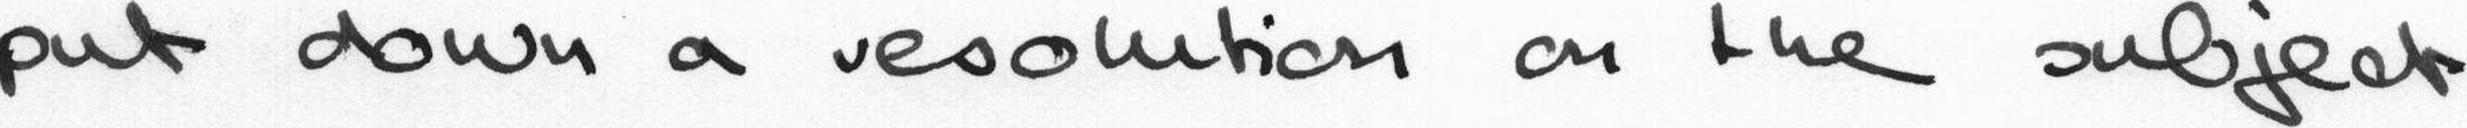

In [6]:
picture_sample = train_set[0]["image"]
print(f"Picture mode: {picture_sample.mode}")
print(f"Picture shape: {transforms.ToTensor()(picture_sample).shape}")
picture_sample

In [7]:
transformations = transforms.Compose([transforms.ToTensor(), transforms.Resize((128, 256))])

Picture after resizing
Picture shape: torch.Size([1, 128, 256])


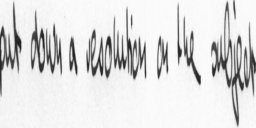

In [8]:
print('Picture after resizing')
resized_picture = transformations(picture_sample)
print(f'Picture shape: {resized_picture.shape}')
transforms.functional.to_pil_image(transformations(picture_sample))

In [9]:
split = ViTSplit(pic_size=(1, 128, 256), split_size=4)

In [10]:
splitted_values = split(resized_picture)
print(f"Number of splitted values should be {256//4}")
print(f"In reality: {len(splitted_values)}")
print(f"If concatenated back values match: {bool((torch.cat(splitted_values, dim=-1) == resized_picture).all())}")

Number of splitted values should be 64
In reality: 64
If concatenated back values match: True


In [11]:
def visualize_horizontal_strips(
    strips: List[torch.Tensor],
    figsize: tuple = (15, 4)
) -> plt.Figure:
    """
    Visualize horizontal image strips in a single row.
    
    Args:
        strips: List of tensors, each of shape (C, H, W) where C=1 or 3
        figsize: Figure size for the complete visualization
    
    Returns:
        matplotlib.figure.Figure: The created figure
    """
    n_strips = len(strips)
    fig, axes = plt.subplots(1, n_strips, figsize=figsize)
    fig.set_facecolor("black")
    
    if n_strips == 1:
        axes = [axes]
    
    for i, (strip, ax) in enumerate(zip(strips, axes)):
        img = strip.squeeze().cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    
    plt.tight_layout()
    return fig

In [13]:
IMG_FOLDER_PATH

'C:\\main\\GitHub\\handwrittenTextRecognitionSystem\\images'

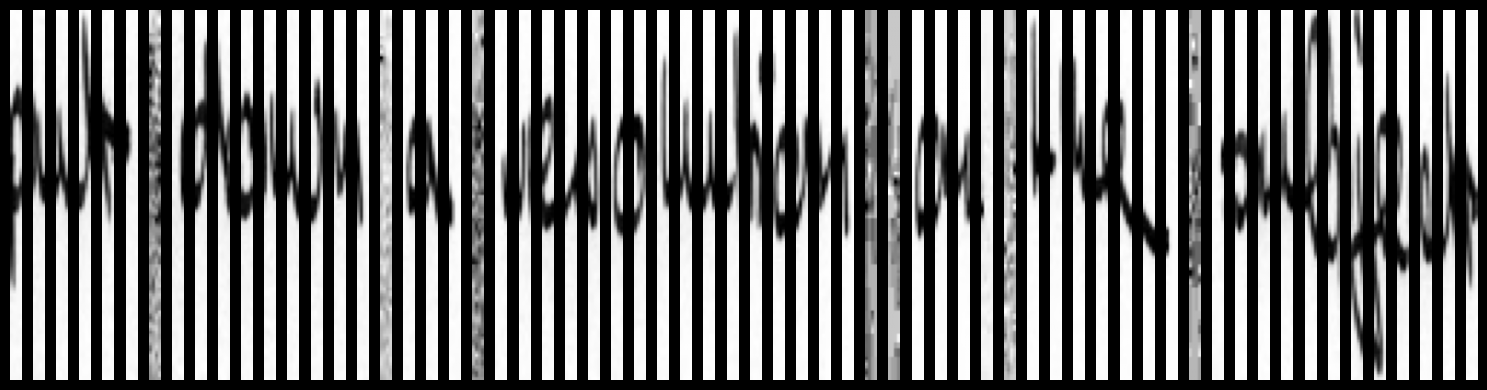

In [15]:
fig = visualize_horizontal_strips(strips=split(resized_picture))

In [ ]:
# fig.savefig(IMG_FOLDER_PATH+r"\\splitted_picture.png")